In [1]:
# Install Packages
!pip install optuna shap catboost lightgbm
rt o
# Import Libraries
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
impoptuna
import shap

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from optuna.samplers import TPESampler

# Setting Global
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/noctican/10-MuhammadArsyadSetiawan-CandraAndikaPutra/refs/heads/main/ai_worker_burnout_attrition_2026.csv')
df.head()

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   employee_id                     1500 non-null   object 
 1   job_role                        1500 non-null   object 
 2   years_experience                1500 non-null   int64  
 3   education_level                 1500 non-null   object 
 4   country                         1500 non-null   object 
 5   industry                        1500 non-null   object 
 6   company_size                    1500 non-null   object 
 7   remote_work_type                1500 non-null   object 
 8   team_size                       1500 non-null   int64  
 9   salary_usd_k                    1500 non-null   int64  
 10  primary_ai_tool                 1500 non-null   object 
 11  ai_tools_used_per_day           1500 non-null   int64  
 12  hours_with_ai_assistance_daily  15

## Data Cleaning

### Handle duplicated data

In [3]:
df.duplicated().sum()

np.int64(0)

### Handle Missing Value

In [4]:
df.isna().sum()

,0
employee_id,0
job_role,0
years_experience,0
education_level,0
country,0
industry,0
company_size,0
remote_work_type,0
team_size,0
salary_usd_k,0


### Removing Unused Cols

In [5]:
df.drop(columns=['employee_id', 'attrition_risk'], inplace=True)

## Feature Engineering 1

### Binning Target

In [6]:
interval = (df['job_satisfaction_1_5'].max() - df['job_satisfaction_1_5'].min())/3
low_max_inter = df['job_satisfaction_1_5'].min() +  interval
med_max_inter = low_max_inter + interval
high_max_inter = med_max_inter + interval

low = [0, low_max_inter]
medium = [low_max_inter, med_max_inter]
high = [med_max_inter, high_max_inter]

print('low: ',low)
print('medium: ',medium)
print('high: ',high)

low:  [0, 2.533333333333333]
medium:  [2.533333333333333, 3.7666666666666666]
high:  [3.7666666666666666, 5.0]


In [7]:
bins = [0, low_max_inter, med_max_inter, high_max_inter]
kelas = ['Low', 'Medium/Neutral', 'High']
df['job_satisfaction_category'] = pd.cut(df['job_satisfaction_1_5'], bins=bins, labels=kelas)

### Math Tunning

In [8]:
math_cols = ['work_life_balance', 'ai_dependency', 'ai_threat_score',
            'upskilling_effort', 'productivity_per_ai_hour', 'salary_per_experience']

class AddMathFeature(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_new = X.copy()

        # 1. Work-Life Balance Score
        if 'burnout_score' in X_new.columns and 'productivity_score' in X_new.columns:
            X_new['work_life_balance'] = X_new['productivity_score'] - X_new['burnout_score']

        # 2. AI Dependency Score
        if 'hours_with_ai_assistance_daily' in X_new.columns and 'ai_tools_used_per_day' in X_new.columns:
            X_new['ai_dependency'] = X_new['hours_with_ai_assistance_daily'] * X_new['ai_tools_used_per_day']

        # 3. AI Threat Score
        if 'ai_replaces_my_tasks_pct' in X_new.columns and 'fear_of_ai_replacement' in X_new.columns:
            fear_map = {'Low': 1, 'Medium': 2, 'High': 3}
            X_new['fear_numeric'] = X_new['fear_of_ai_replacement'].map(fear_map)
            X_new['ai_threat_score'] = X_new['ai_replaces_my_tasks_pct'] * X_new['fear_numeric']
            X_new.drop('fear_numeric', axis=1, inplace=True)

        # 4. Upskilling Effort
        if 'weekly_ai_upskilling_hrs' in X_new.columns and 'years_experience' in X_new.columns:
            X_new['upskilling_effort'] = X_new['weekly_ai_upskilling_hrs'] / (X_new['years_experience'] + 1)

        # 5. Productivity per hour with AI
        if 'productivity_score' in X_new.columns and 'hours_with_ai_assistance_daily' in X_new.columns:
            X_new['productivity_per_ai_hour'] = X_new['productivity_score'] / (X_new['hours_with_ai_assistance_daily'] + 1)

        # 6. Experience to salary ratio
        if 'years_experience' in X_new.columns and 'salary_usd_k' in X_new.columns:
            X_new['salary_per_experience'] = X_new['salary_usd_k'] / (X_new['years_experience'] + 1)

        return X_new


math_tunning = AddMathFeature()
df_w_math = df.copy()
df_w_math = math_tunning.fit_transform(df_w_math)

## Preprocessing

### Visualisasi Distribusi

In [9]:
def show_distribution(df, cols):
  n_cols = 3
  n_rows = (len(cols) + n_cols - 1) // n_cols

  fig, ax = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
  ax = ax.flatten()

  for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=ax[i])
    ax[i].set_title(f'Distribusi: {col}')
    ax[i].set_xlabel('')
    ax[i].set_ylabel('Frekuensi')

  plt.tight_layout()
  plt.show()

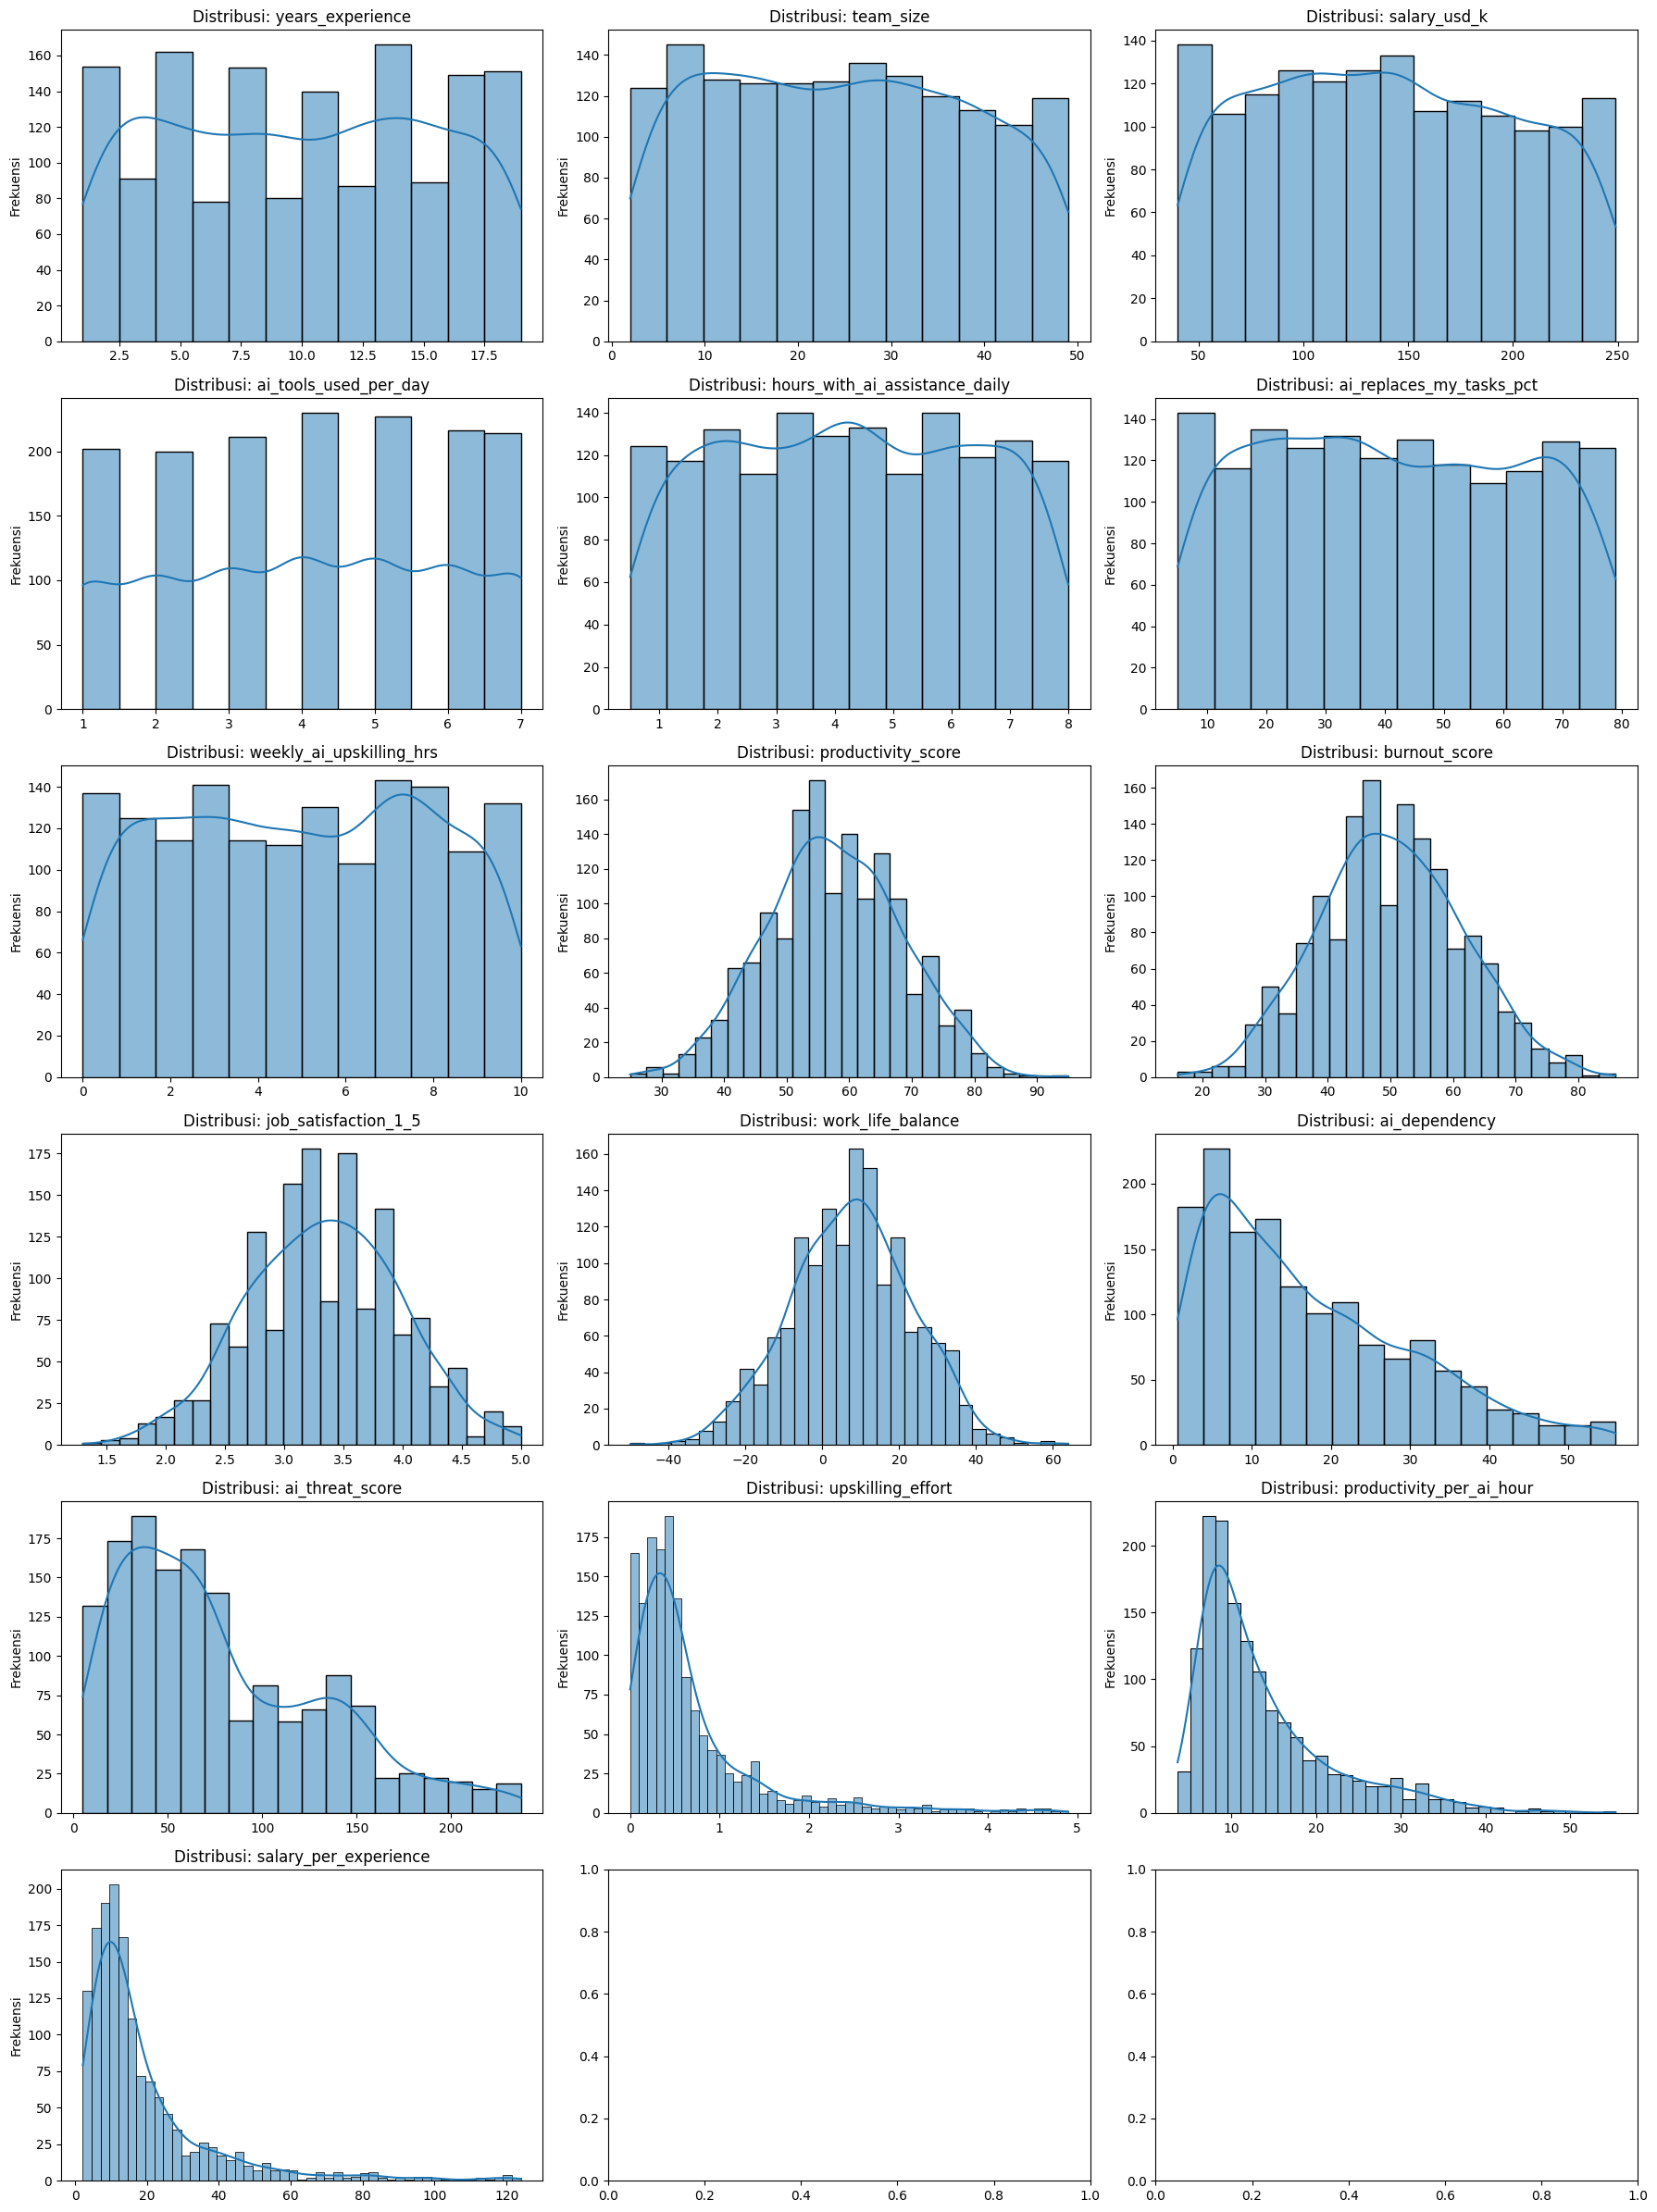

In [10]:
num_cols = df_w_math.select_dtypes(include=['number']).columns
show_distribution(df_w_math, num_cols)

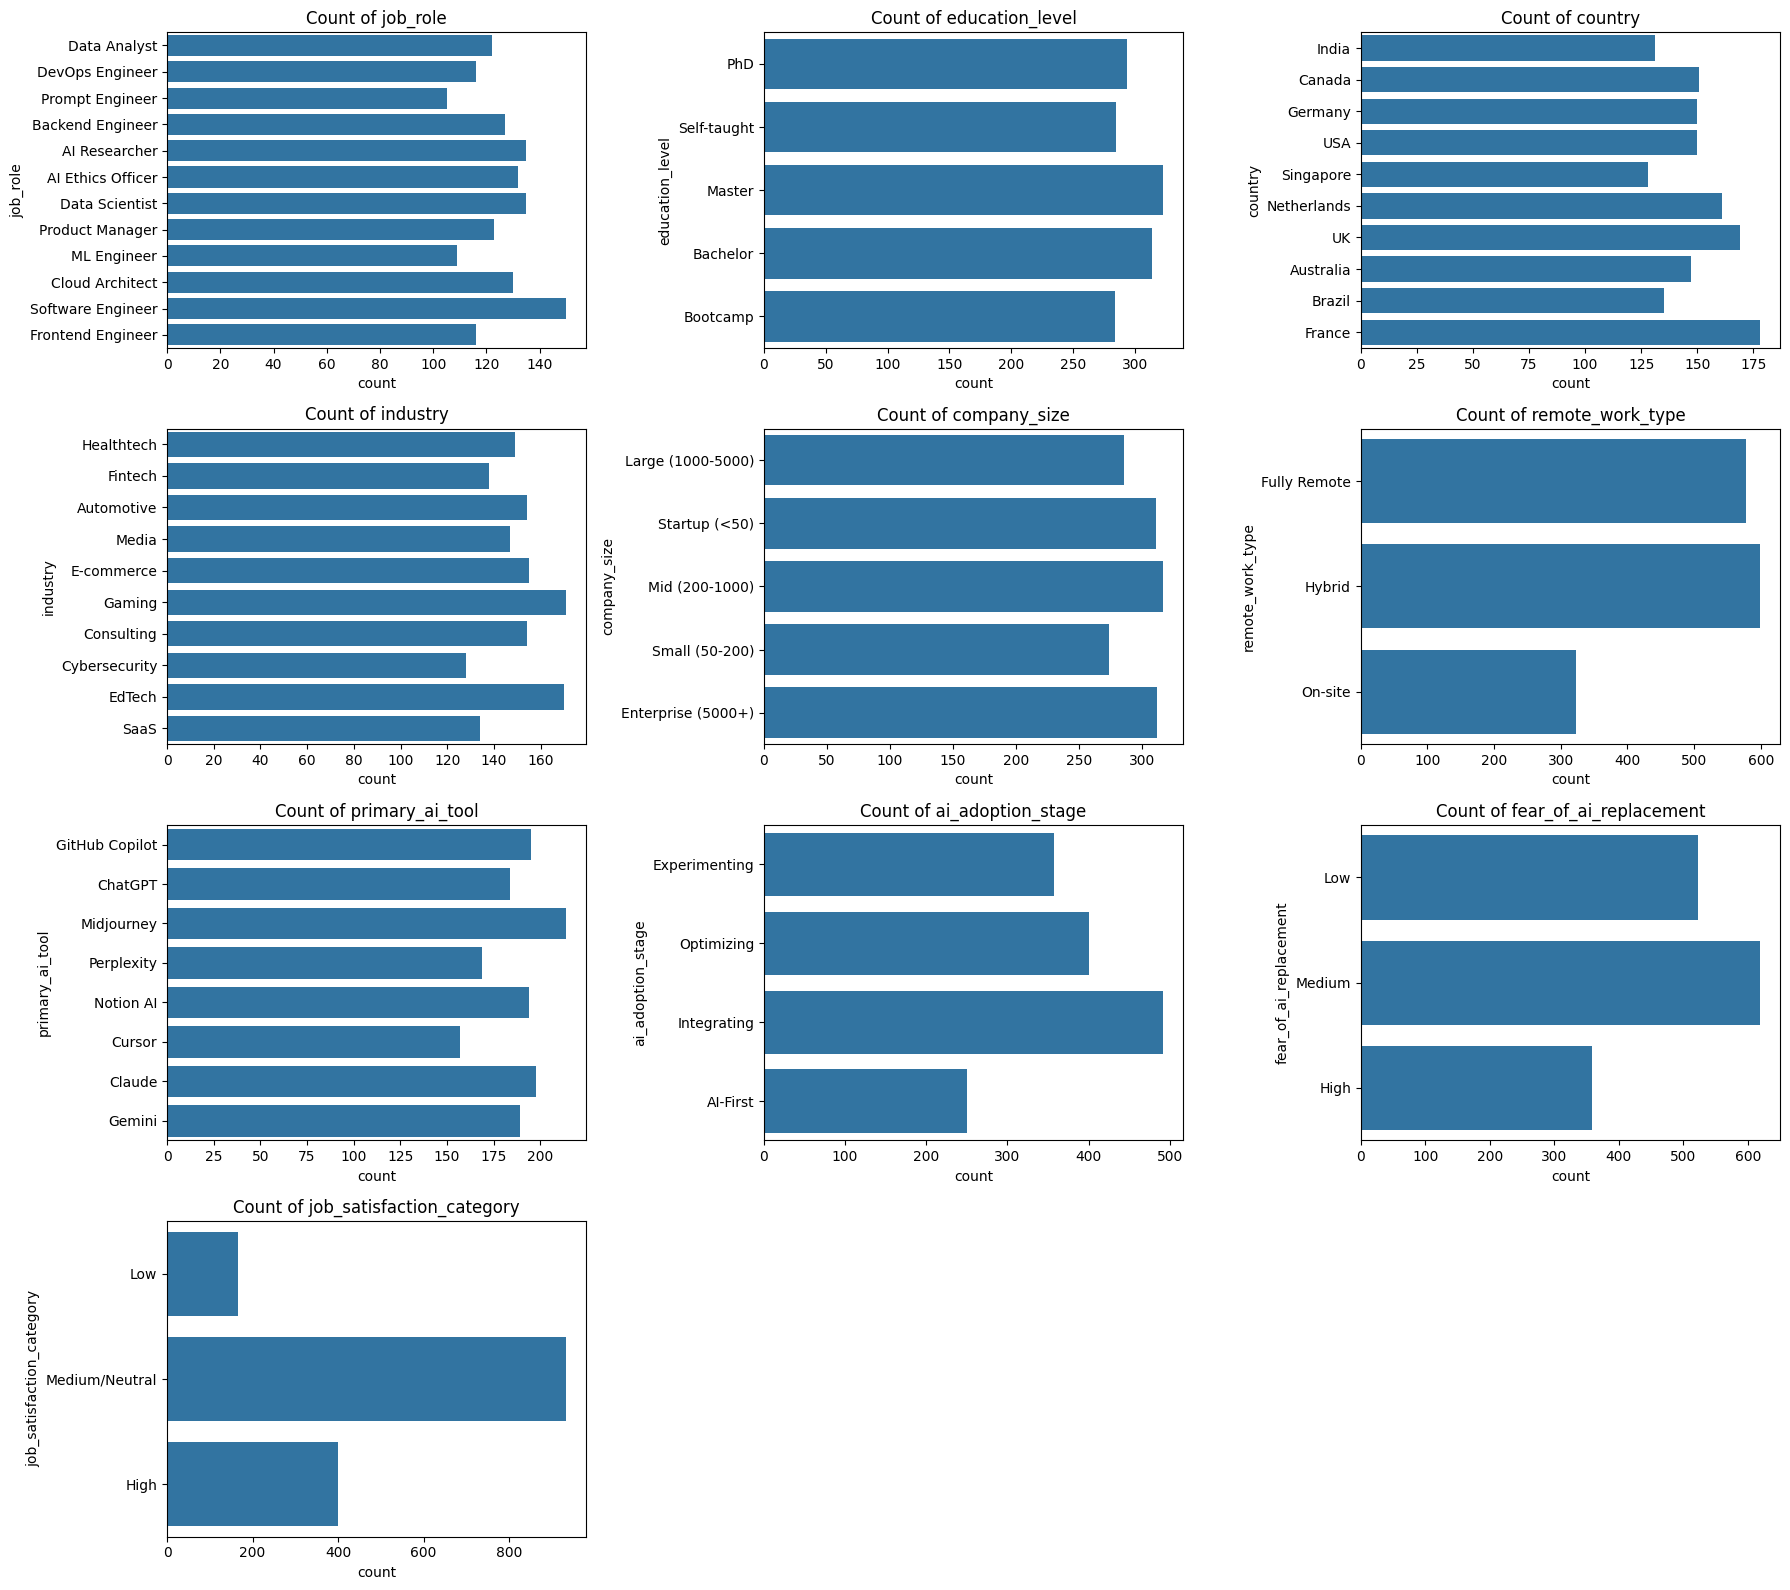

In [11]:
def show_cat_distribution(df, cols):
  n_cols = 3
  n_rows = (len(cols) + n_cols - 1) // n_cols

  plt.figure(figsize=(18, 4*n_rows))

  for i, col in enumerate(cols, 1):
      plt.subplot(n_rows, n_cols, i)
      sns.countplot(data=df, y=col)
      plt.title(f'Count of {col}')

  plt.tight_layout()
  plt.show()

all_cat_cols = df.select_dtypes(include=['object', 'category']).columns
show_cat_distribution(df, all_cat_cols)

### Normalisasi

In [12]:
std_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

std_cols = ['productivity_score', 'burnout_score'] + math_cols
minmax_cols = ['years_experience', 'team_size', 'salary_usd_k', 'ai_tools_used_per_day', 'hours_with_ai_assistance_daily', 'ai_replaces_my_tasks_pct', 'weekly_ai_upskilling_hrs']

### Encoding

In [13]:
cat_cols = df.select_dtypes('object').columns
cat_cols

Index(['job_role', 'education_level', 'country', 'industry', 'company_size',
       'remote_work_type', 'primary_ai_tool', 'ai_adoption_stage',
       'fear_of_ai_replacement'],
      dtype='object')

In [14]:
for col in cat_cols:
    print(f'{col}: {df[col].unique()}')

job_role: ['Data Analyst' 'DevOps Engineer' 'Prompt Engineer' 'Backend Engineer'
 'AI Researcher' 'AI Ethics Officer' 'Data Scientist' 'Product Manager'
 'ML Engineer' 'Cloud Architect' 'Software Engineer' 'Frontend Engineer']
education_level: ['PhD' 'Self-taught' 'Master' 'Bachelor' 'Bootcamp']
country: ['India' 'Canada' 'Germany' 'USA' 'Singapore' 'Netherlands' 'UK'
 'Australia' 'Brazil' 'France']
industry: ['Healthtech' 'Fintech' 'Automotive' 'Media' 'E-commerce' 'Gaming'
 'Consulting' 'Cybersecurity' 'EdTech' 'SaaS']
company_size: ['Large (1000-5000)' 'Startup (<50)' 'Mid (200-1000)' 'Small (50-200)'
 'Enterprise (5000+)']
remote_work_type: ['Fully Remote' 'Hybrid' 'On-site']
primary_ai_tool: ['GitHub Copilot' 'ChatGPT' 'Midjourney' 'Perplexity' 'Notion AI' 'Cursor'
 'Claude' 'Gemini']
ai_adoption_stage: ['Experimenting' 'Optimizing' 'Integrating' 'AI-First']
fear_of_ai_replacement: ['Low' 'Medium' 'High']


### Ordinal

In [15]:
target_mapping = {'Low': 0, 'Medium/Neutral': 1, 'High': 2}

education_mapping = ['Self-taught', 'Bootcamp', 'Bachelor', 'Master', 'PhD']

company_size_mapping = ['Startup (<50)', 'Small (50-200)', 'Mid (200-1000)', 'Large (1000-5000)', 'Enterprise (5000+)']

ai_adoption_mapping = ['Experimenting', 'Optimizing', 'Integrating', 'AI-First']

fear_mapping = ['Low', 'Medium', 'High']

ordinal_cols = [
    'education_level',
    'company_size',
    'ai_adoption_stage',
    'fear_of_ai_replacement',
]

ordinal_cols_mapping = [
    education_mapping,
    company_size_mapping,
    ai_adoption_mapping,
    fear_mapping,
]

In [16]:
df['job_satisfaction_category'] = df['job_satisfaction_category'].map(target_mapping)
ord_enc = OrdinalEncoder(categories=ordinal_cols_mapping)

### Nominal

In [17]:
ohe_cols = [
    'job_role',
    'country',
    'industry',
    'remote_work_type',
    'primary_ai_tool'
]

In [18]:
ohe_enc = OneHotEncoder(drop='first')

### Balancing Data

In [19]:
smote = SMOTE(random_state=42)

## Data Splitting

In [20]:
X = df.drop(['job_satisfaction_category', 'job_satisfaction_1_5'], axis=1)
y = df['job_satisfaction_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


## Feature Engineering 2

In [21]:
prepo_w_scaler = ColumnTransformer([
    ('std_scaler', std_scaler, std_cols),
    ('minmax_scaler', minmax_scaler, minmax_cols),
    ('ordinal', ord_enc, ordinal_cols),
    ('ohe', ohe_enc, ohe_cols)
])

prepo_wo_scaler = ColumnTransformer([
    ('ordinal', ord_enc, ordinal_cols),
    ('ohe', ohe_enc, ohe_cols)
])

In [22]:
def getPipeline(model, wScale = True, wSmote = True):
  prepo = prepo_w_scaler if wScale else prepo_wo_scaler
  step_smote = smote if wSmote else None

  pipeline = ImbPipeline([
      ('math_tunning', math_tunning),
      ('prepo', prepo),
      ('smote', step_smote),
      ('model', model)
  ])

  return pipeline

In [ ]:
# mengurangi fitur menggunakan fitur terbaik xgb
def objective_shap_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300), # Nggak usah banyak-banyak
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'random_state': 42,
        'n_jobs': -1
    }

    model = XGBClassifier(**param)

    pipeline = getPipeline(model, wScale=True, wSmote=True)

    score = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='f1_macro')
    return score.mean()

print("Tuning XGBoost untuk SHAP...")
study_shap = optuna.create_study(direction='maximize')
study_shap.optimize(objective_shap_xgb, n_trials=25)

print("Selesai! Parameter sementara:", study_shap.best_params)

Tuning XGBoost untuk SHAP...
Selesai! Parameter sementara: {'n_estimators': 300, 'learning_rate': 0.019552506391646494, 'max_depth': 7}


In [ ]:
X_train_math = math_tunning.fit_transform(X_train)
X_train_transformed = prepo_w_scaler.fit_transform(X_train_math)
feat_name_trans = prepo_w_scaler.get_feature_names_out()
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_transformed, y_train)

xgb_shap_model = XGBClassifier(**study_shap.best_params, random_state=42, n_jobs=-1)
xgb_shap_model.fit(X_train_resampled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.019552506391646494, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


Menghitung nilai SHAP

📊 SHAP Summary Plot:


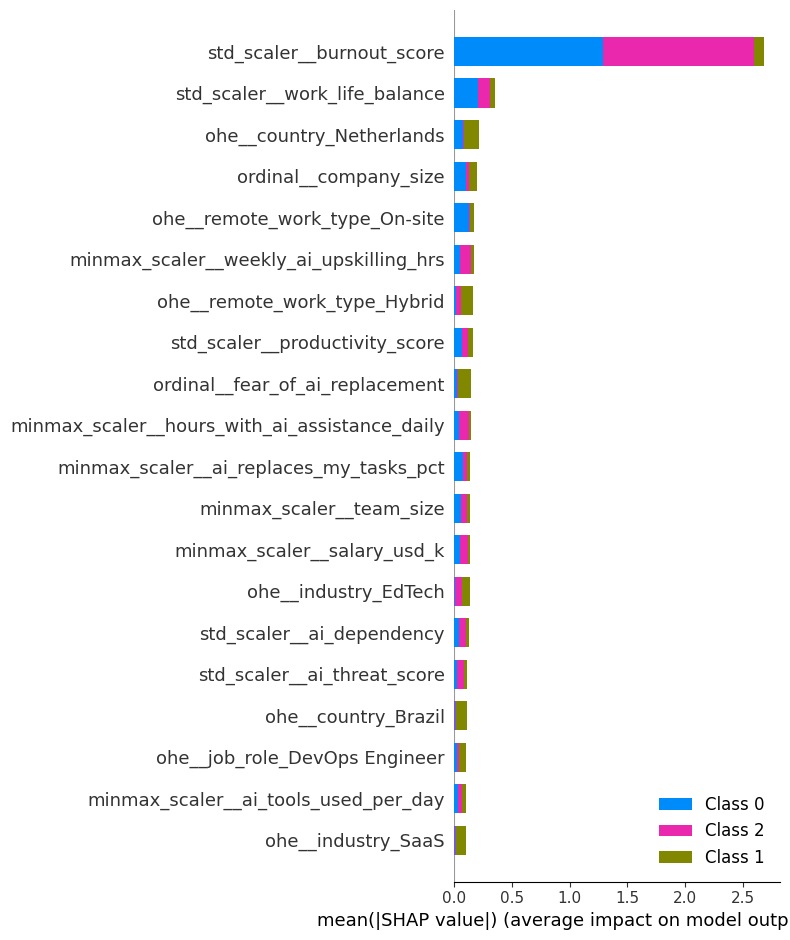


🏆 Ranking Fitur SHAP:
                                Fitur_Encoded  Dampak_SHAP
                    std_scaler__burnout_score     0.896604
                std_scaler__work_life_balance     0.116538
                     ohe__country_Netherlands     0.072556
                        ordinal__company_size     0.065343
                ohe__remote_work_type_On-site     0.057521
      minmax_scaler__weekly_ai_upskilling_hrs     0.057448
                 ohe__remote_work_type_Hybrid     0.054113
               std_scaler__productivity_score     0.053911
              ordinal__fear_of_ai_replacement     0.048658
minmax_scaler__hours_with_ai_assistance_daily     0.048039
      minmax_scaler__ai_replaces_my_tasks_pct     0.046196
                     minmax_scaler__team_size     0.045684
                  minmax_scaler__salary_usd_k     0.045041
                         ohe__industry_EdTech     0.044221
                    std_scaler__ai_dependency     0.043220
                  std_scaler__ai_

In [ ]:
print("\nMenghitung nilai SHAP")
explainer = shap.TreeExplainer(xgb_shap_model)
shap_values = explainer.shap_values(X_train_resampled)

print("\n📊 SHAP Summary Plot:")
shap.summary_plot(shap_values, X_train_resampled, feature_names=feat_name_trans, plot_type='bar')

if isinstance(shap_values, list):
    mean_impact = np.zeros(shap_values[0].shape[1])
    for vals in shap_values:
        mean_impact += np.abs(vals).mean(axis=0)
    mean_impact = mean_impact / len(shap_values)
elif len(shap_values.shape) == 3:
    mean_impact = np.abs(shap_values).mean(axis=0).mean(axis=1)
else:
    mean_impact = np.abs(shap_values).mean(axis=0)

# Masukkan ke DataFrame
df_shap_rank = pd.DataFrame({
    'Fitur_Encoded': feat_name_trans,
    'Dampak_SHAP': mean_impact
}).sort_values(by='Dampak_SHAP', ascending=False)

print("\n🏆 Ranking Fitur SHAP:")
print(df_shap_rank.head(-1).to_string(index=False))

In [23]:
selected_feat = [
    'burnout_score', 'country', 'remote_work_type', 'weekly_ai_upskilling_hrs',
    'productivity_score', 'hours_with_ai_assistance_daily', 'salary_usd_k',
    'fear_of_ai_replacement', 'team_size', 'ai_replaces_my_tasks_pct',
    'primary_ai_tool', 'years_experience', 'education_level', 'ai_tools_used_per_day'
]

final_std_cols = [col for col in std_cols if col in selected_feat + math_cols]
final_minmax_cols = [col for col in minmax_cols if col in selected_feat]
final_ohe_cols = [col for col in ohe_cols if col in selected_feat]

final_ordinal_cols = []
final_ordinal_mapping = []
for col, mapping in zip(ordinal_cols, ordinal_cols_mapping):
    if col in selected_feat:
        final_ordinal_cols.append(col)
        final_ordinal_mapping.append(mapping)

X_train = X_train[selected_feat]
X_test = X_test[selected_feat]

In [24]:
# update transformer
final_ord_enc = OrdinalEncoder(categories=final_ordinal_mapping)

prepo_w_scaler = ColumnTransformer([
    ('std_scaler', std_scaler, final_std_cols),
    ('minmax_scaler', minmax_scaler, final_minmax_cols),
    ('ordinal', final_ord_enc, final_ordinal_cols),
    ('ohe', ohe_enc, final_ohe_cols)
])

prepo_wo_scaler = ColumnTransformer([
    ('ordinal', final_ord_enc, final_ordinal_cols),
    ('ohe', ohe_enc, final_ohe_cols)
])

## Hyperparameter Tuning & Modelling

### Base

In [ ]:
def objective_base_rf(trial, wScale = True, wSmote = True):
  param = {
      'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
      'max_depth': trial.suggest_int('max_depth', 5, 50),
      'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
      'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
      'random_state': 42
  }

  model = RandomForestClassifier(**param)
  pipeline = getPipeline(model, wScale, wSmote)

  score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_macro')

  return score.mean()

In [ ]:
def objective_base_xgb(trial, wScale = True, wSmote = True):
  param = {
      'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
      'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
      'max_depth': trial.suggest_int('max_depth', 3, 10), # Jangan terlalu dalam
      'subsample': trial.suggest_float('subsample', 0.5, 1.0), # Mencegah overfitting
      'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
      'random_state': 42,
      'n_jobs': -1,
  }

  model = XGBClassifier(**param)
  pipeline = getPipeline(model, wScale, wSmote)

  score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_macro')

  return score.mean()

In [ ]:
def objective_base_lgbm(trial, wScale = True, wSmote = True):
  param = {
      'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
      'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
      'num_leaves': trial.suggest_int('num_leaves', 20, 100),
      'max_depth': trial.suggest_int('max_depth', 3, 12),
      'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
      'subsample': trial.suggest_float('subsample', 0.5, 1.0),
      'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
      'random_state': 42,
      'verbose': -1,
      'n_jobs': -1,
  }

  model = LGBMClassifier(**param)
  pipeline = getPipeline(model, wScale, wSmote)

  score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_macro')

  return score.mean()

In [ ]:
def objective_base_catboost(trial, wScale = True, wSmote = True):
  param = {
      'iterations': trial.suggest_int('iterations', 100, 1000),
      'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
      'depth': trial.suggest_int('depth', 4, 10),
      'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
      'random_state': 42,
      'verbose': False,
      'thread_count': -1
  }

  model = CatBoostClassifier(**param)
  pipeline = getPipeline(model, wScale, wSmote)

  score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_macro')

  return score.mean()

In [ ]:
def objective_base_et(trial, wScale = True, wSmote = True):
  param = {
      'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
      'max_depth': trial.suggest_int('max_depth', 5, 50),
      'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
      'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
      'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
      'random_state': 42,
      'n_jobs': -1
  }

  model = ExtraTreesClassifier(**param)
  pipeline = getPipeline(model, wScale, wSmote)

  score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_macro')

  return score.mean()

In [ ]:
def objective_base_logres(trial, wScale = True, wSmote = True):
  param = {
      'C': trial.suggest_float('C', 1e-4, 10.0, log=True),
      'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear']),
      'max_iter': 1000,
      'random_state': 42
  }

  model = LogisticRegression(**param)
  pipeline = getPipeline(model, wScale, wSmote)

  score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_macro')

  return score.mean()

### Running Base

In [ ]:
best_base = {}
objective_fn_base = {
    'Random Forest' : objective_base_rf,
    'XGBoost' : objective_base_xgb,
    'Logistic Regression' : objective_base_logres,
    'CatBoost' : objective_base_catboost,
    'LightGBM' : objective_base_lgbm,
    'Extra Trees' : objective_base_et,
}

In [ ]:
algo_name = 'Random Forest'
fn_objective = objective_fn_base[algo_name]
print(f'Mencari hyperparameter {algo_name} terbaik')
best_base[algo_name] = []
for i in range(3):
    wScale = False if i == 1 else True
    wSmote = False if i == 0 else True
    print(f'Scale: {wScale}, Smote: {wSmote}')

    const_sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=const_sampler)
    study.optimize(lambda trial: fn_objective(trial, wScale, wSmote), n_trials=50)

    print('Hyperparameter terbaik ditemukan!')
    print(study.best_params)
    print(f'F1-Score: {study.best_value}')

    best_base[algo_name].append({
        'param': study.best_params,
        'f1_score': study.best_value,
        'wScale': wScale,
        'wSmote': wSmote,
    })

Mencari hyperparameter Random Forest terbaik
Scale: True, Smote: False
Hyperparameter terbaik ditemukan!
{'n_estimators': 679, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 1}
F1-Score: 0.41441395785541957
Scale: False, Smote: True
Hyperparameter terbaik ditemukan!
{'n_estimators': 268, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 18}
F1-Score: 0.33808933460536406
Scale: True, Smote: True
Hyperparameter terbaik ditemukan!
{'n_estimators': 874, 'max_depth': 50, 'min_samples_split': 11, 'min_samples_leaf': 6}
F1-Score: 0.5091396521049764


In [ ]:
algo_name = 'XGBoost'
fn_objective = objective_fn_base[algo_name]
print(f'Mencari hyperparameter {algo_name} terbaik')
best_base[algo_name] = []
for i in range(3):
    wScale = False if i == 1 else True
    wSmote = False if i == 0 else True
    print(f'Scale: {wScale}, Smote: {wSmote}')

    const_sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=const_sampler)
    study.optimize(lambda trial: fn_objective(trial, wScale, wSmote), n_trials=50)

    print('Hyperparameter terbaik ditemukan!')
    print(study.best_params)
    print(f'F1-Score: {study.best_value}')

    best_base[algo_name].append({
        'param': study.best_params,
        'f1_score': study.best_value,
        'wScale': wScale,
        'wSmote': wSmote,
    })

Mencari hyperparameter XGBoost terbaik
Scale: True, Smote: False
Hyperparameter terbaik ditemukan!
{'n_estimators': 930, 'learning_rate': 0.21924570391692522, 'max_depth': 7, 'subsample': 0.7809048443111638, 'colsample_bytree': 0.9627355533796078}
F1-Score: 0.46636523713552763
Scale: False, Smote: True
Hyperparameter terbaik ditemukan!
{'n_estimators': 779, 'learning_rate': 0.012971494264034423, 'max_depth': 8, 'subsample': 0.5253161028324531, 'colsample_bytree': 0.7058531539503271}
F1-Score: 0.341781822868363
Scale: True, Smote: True
Hyperparameter terbaik ditemukan!
{'n_estimators': 891, 'learning_rate': 0.004106658569963658, 'max_depth': 3, 'subsample': 0.9422977190401586, 'colsample_bytree': 0.689410135110179}
F1-Score: 0.521145397432903


In [ ]:
algo_name = 'Logistic Regression'
fn_objective = objective_fn_base[algo_name]
print(f'Mencari hyperparameter {algo_name} terbaik')
best_base[algo_name] = []
for i in range(3):
    wScale = False if i == 1 else True
    wSmote = False if i == 0 else True
    print(f'Scale: {wScale}, Smote: {wSmote}')

    const_sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=const_sampler)
    study.optimize(lambda trial: fn_objective(trial, wScale, wSmote), n_trials=50)

    print('Hyperparameter terbaik ditemukan!')
    print(study.best_params)
    print(f'F1-Score: {study.best_value}')

    best_base[algo_name].append({
        'param': study.best_params,
        'f1_score': study.best_value,
        'wScale': wScale,
        'wSmote': wSmote,
    })

Mencari hyperparameter Logistic Regression terbaik
Scale: True, Smote: False
Hyperparameter terbaik ditemukan!
{'C': 0.12600887333013197, 'solver': 'lbfgs'}
F1-Score: 0.47232398301664125
Scale: False, Smote: True
Hyperparameter terbaik ditemukan!
{'C': 0.31186935490258083, 'solver': 'lbfgs'}
F1-Score: 0.3119751810463307
Scale: True, Smote: True
Hyperparameter terbaik ditemukan!
{'C': 0.06157621574057401, 'solver': 'lbfgs'}
F1-Score: 0.4946016106530108


In [ ]:
# algo_name = 'CatBoost'
fn_objective = objective_fn_base[algo_name]
print(f'Mencari hyperparameter {algo_name} terbaik')
best_base[algo_name] = []
for i in range(3):
    wScale = False if i == 1 else True
    wSmote = False if i == 0 else True
    print(f'Scale: {wScale}, Smote: {wSmote}')

    const_sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=const_sampler)
    study.optimize(lambda trial: fn_objective(trial, wScale, wSmote), n_trials=50)

    print('Hyperparameter terbaik ditemukan!')
    print(study.best_params)
    print(f'F1-Score: {study.best_value}')

    best_base[algo_name].append({
        'param': study.best_params,
        'f1_score': study.best_value,
        'wScale': wScale,
        'wSmote': wSmote,
    })

Mencari hyperparameter CatBoost terbaik
Scale: True, Smote: False
Hyperparameter terbaik ditemukan!
{'iterations': 110, 'learning_rate': 0.21751661643618675, 'depth': 4, 'l2_leaf_reg': 7.992042433893281}
F1-Score: 0.48379480610782155
Scale: False, Smote: True
Hyperparameter terbaik ditemukan!
{'iterations': 135, 'learning_rate': 0.0053352059844099416, 'depth': 7, 'l2_leaf_reg': 2.565351510392949}
F1-Score: 0.350955233115089
Scale: True, Smote: True
Hyperparameter terbaik ditemukan!
{'iterations': 611, 'learning_rate': 0.010781119597332514, 'depth': 5, 'l2_leaf_reg': 7.44038308212079}
F1-Score: 0.5169672398201461


In [ ]:
algo_name = 'LightGBM'
fn_objective = objective_fn_base[algo_name]
print(f'Mencari hyperparameter {algo_name} terbaik')
best_base[algo_name] = []
for i in range(3):
    wScale = False if i == 1 else True
    wSmote = False if i == 0 else True
    print(f'Scale: {wScale}, Smote: {wSmote}')

    const_sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=const_sampler)
    study.optimize(lambda trial: fn_objective(trial, wScale, wSmote), n_trials=50)

    print('Hyperparameter terbaik ditemukan!')
    print(study.best_params)
    print(f'F1-Score: {study.best_value}')

    best_base[algo_name].append({
        'param': study.best_params,
        'f1_score': study.best_value,
        'wScale': wScale,
        'wSmote': wSmote,
    })

Mencari hyperparameter LightGBM terbaik
Scale: True, Smote: False
Hyperparameter terbaik ditemukan!
{'n_estimators': 813, 'learning_rate': 0.13854667115225974, 'num_leaves': 76, 'max_depth': 10, 'min_child_samples': 40, 'subsample': 0.7256494499257813, 'colsample_bytree': 0.9316782524656649}
F1-Score: 0.4711734377246488
Scale: False, Smote: True
Hyperparameter terbaik ditemukan!
{'n_estimators': 633, 'learning_rate': 0.0013033567475147442, 'num_leaves': 69, 'max_depth': 4, 'min_child_samples': 12, 'subsample': 0.9744427686266666, 'colsample_bytree': 0.9828160165372797}
F1-Score: 0.33799084088089215
Scale: True, Smote: True
Hyperparameter terbaik ditemukan!
{'n_estimators': 915, 'learning_rate': 0.0013049867467967928, 'num_leaves': 89, 'max_depth': 10, 'min_child_samples': 42, 'subsample': 0.9922375964136952, 'colsample_bytree': 0.5030114997999782}
F1-Score: 0.5341474250878624


In [ ]:
algo_name = 'Extra Trees'
fn_objective = objective_fn_base[algo_name]
print(f'Mencari hyperparameter {algo_name} terbaik')
best_base[algo_name] = []
for i in range(3):
    wScale = False if i == 1 else True
    wSmote = False if i == 0 else True
    print(f'Scale: {wScale}, Smote: {wSmote}')

    const_sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=const_sampler)
    study.optimize(lambda trial: fn_objective(trial, wScale, wSmote), n_trials=50)

    print('Hyperparameter terbaik ditemukan!')
    print(study.best_params)
    print(f'F1-Score: {study.best_value}')

    best_base[algo_name].append({
        'param': study.best_params,
        'f1_score': study.best_value,
        'wScale': wScale,
        'wSmote': wSmote,
    })

Mencari hyperparameter Extra Trees terbaik
Scale: True, Smote: False
Hyperparameter terbaik ditemukan!
{'n_estimators': 179, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': None}
F1-Score: 0.4367713847548874
Scale: False, Smote: True
Hyperparameter terbaik ditemukan!
{'n_estimators': 706, 'max_depth': 46, 'min_samples_split': 16, 'min_samples_leaf': 7, 'max_features': 'log2'}
F1-Score: 0.3548315140854336
Scale: True, Smote: True
Hyperparameter terbaik ditemukan!
{'n_estimators': 217, 'max_depth': 24, 'min_samples_split': 12, 'min_samples_leaf': 15, 'max_features': None}
F1-Score: 0.5175198725758243


In [ ]:
# for algo_name, fn_objective in objective_fn_base.items():
#   print(f'Mencari hyperparameter {algo_name} terbaik')
#   best_base[algo_name] = []
#   for i in range(3):
#     wScale = False if i == 1 else True
#     wSmote = False if i == 0 else True
#     print(f'Scale: {wScale}, Smote: {wSmote}')

#     const_sampler = TPESampler(seed=42)
#     study = optuna.create_study(direction='maximize', sampler=const_sampler)
#     study.optimize(lambda trial: fn_objective(trial, wScale, wSmote), n_trials=30)

#     print('Hyperparameter terbaik ditemukan!')
#     print(study.best_params)
#     print(f'F1-Score: {study.best_value}')

#     best_base[algo_name].append({
#         'param': study.best_params,
#         'f1_score': study.best_value,
#         'wScale': wScale,
#         'wSmote': wSmote,
#     })

### Level 1

In [25]:
best_base = {
    'Random Forest' : [
        {
            'param': {'n_estimators': 679, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 1},
            'f1_score': 0.41441395785541957,
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'n_estimators': 268, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 18},
            'f1_score': 0.33808933460536406,
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'n_estimators': 874, 'max_depth': 50, 'min_samples_split': 11, 'min_samples_leaf': 6},
            'f1_score': 0.5091396521049764,
            'wScale': True,
            'wSmote': True,
        },
    ],
    'XGBoost' : [
        {
            'param': {'n_estimators': 930, 'learning_rate': 0.21924570391692522, 'max_depth': 7, 'subsample': 0.7809048443111638, 'colsample_bytree': 0.9627355533796078},
            'f1_score': 0.46636523713552763,
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'n_estimators': 779, 'learning_rate': 0.012971494264034423, 'max_depth': 8, 'subsample': 0.5253161028324531, 'colsample_bytree': 0.7058531539503271},
            'f1_score': 0.341781822868363,
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'n_estimators': 891, 'learning_rate': 0.004106658569963658, 'max_depth': 3, 'subsample': 0.9422977190401586, 'colsample_bytree': 0.689410135110179},
            'f1_score': 0.521145397432903,
            'wScale': True,
            'wSmote': True,
        },
    ],
    'Logistic Regression' : [
        {
            'param': {'C': 0.12600887333013197, 'solver': 'lbfgs'},
            'f1_score': 0.47232398301664125,
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'C': 0.31186935490258083, 'solver': 'lbfgs'},
            'f1_score': 0.3119751810463307,
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'C': 0.06157621574057401, 'solver': 'lbfgs'},
            'f1_score': 0.4946016106530108,
            'wScale': True,
            'wSmote': True,
        },
    ],
    'CatBoost' : [
        {
            'param': {'iterations': 110, 'learning_rate': 0.21751661643618675, 'depth': 4, 'l2_leaf_reg': 7.992042433893281},
            'f1_score': 0.48379480610782155,
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'iterations': 135, 'learning_rate': 0.0053352059844099416, 'depth': 7, 'l2_leaf_reg': 2.565351510392949},
            'f1_score': 0.350955233115089,
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'iterations': 611, 'learning_rate': 0.010781119597332514, 'depth': 5, 'l2_leaf_reg': 7.44038308212079},
            'f1_score': 0.5169672398201461,
            'wScale': True,
            'wSmote': True,
        },
    ],
    'LightGBM' : [
        {
            'param': {'n_estimators': 813, 'learning_rate': 0.13854667115225974, 'num_leaves': 76, 'max_depth': 10, 'min_child_samples': 40, 'subsample': 0.7256494499257813, 'colsample_bytree': 0.9316782524656649},
            'f1_score': 0.4711734377246488,
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'n_estimators': 633, 'learning_rate': 0.0013033567475147442, 'num_leaves': 69, 'max_depth': 4, 'min_child_samples': 12, 'subsample': 0.9744427686266666, 'colsample_bytree': 0.9828160165372797},
            'f1_score': 0.33799084088089215,
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'n_estimators': 915, 'learning_rate': 0.0013049867467967928, 'num_leaves': 89, 'max_depth': 10, 'min_child_samples': 42, 'subsample': 0.9922375964136952, 'colsample_bytree': 0.5030114997999782},
            'f1_score': 0.5341474250878624,
            'wScale': True,
            'wSmote': True,
        },
    ],
    'Extra Trees' : [
        {
            'param': {'n_estimators': 179, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': None},
            'f1_score': 0.4367713847548874,
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'n_estimators': 706, 'max_depth': 46, 'min_samples_split': 16, 'min_samples_leaf': 7, 'max_features': 'log2'},
            'f1_score': 0.3548315140854336,
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'n_estimators': 217, 'max_depth': 24, 'min_samples_split': 12, 'min_samples_leaf': 15, 'max_features': None},
            'f1_score': 0.5175198725758243,
            'wScale': True,
            'wSmote': True,
        },
    ],
}

In [26]:
def objective_meta_logres(trial, wScale = True, wSmote = True):
  param = {
      'C': trial.suggest_float('C', 1e-4, 10.0, log=True),
      'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear']),
      'max_iter': 1000,
      'random_state': 42
  }

  i = 0 if not wSmote else 1 if wScale else 2

  base = [
      ('rf', RandomForestClassifier(**best_base['Random Forest'][i]['param'], random_state=42)),
      ('xgb', XGBClassifier(**best_base['XGBoost'][i]['param'], random_state=42, n_jobs=-1)),
      ('logres', LogisticRegression(**best_base['Logistic Regression'][i]['param'], random_state=42, max_iter=1000)),
  ]

  lvl_1 = LogisticRegression(**param)

  stacking = StackingClassifier(estimators=base, final_estimator=lvl_1)

  pipeline = getPipeline(stacking, wScale, wSmote)

  score = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='f1_macro')

  return score.mean()

In [27]:
def objective_meta_ridge(trial, wScale = True, wSmote = True):
  param = {
      'alpha': trial.suggest_float('alpha', 0.1, 10.0, log=True),
      'solver': trial.suggest_categorical('solver', ['auto', 'svd', 'cholesky', 'sag']),
      'random_state': 42
  }

  i = 0 if not wSmote else 1 if wScale else 2

  base = [
      ('catboost', CatBoostClassifier(**best_base['CatBoost'][i]['param'], random_state=42, verbose=False, thread_count=-1)),
      ('lgbm', LGBMClassifier(**best_base['LightGBM'][i]['param'], random_state=42, verbose=-1, n_jobs=-1)),
      ('et', ExtraTreesClassifier(**best_base['Extra Trees'][i]['param'], random_state=42, n_jobs=-1)),
  ]

  lvl_1 = RidgeClassifier(**param)

  stacking = StackingClassifier(estimators=base, final_estimator=lvl_1)

  pipeline = getPipeline(stacking, wScale, wSmote)

  score = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='f1_macro')

  return score.mean()

In [28]:
best_meta = {}
objective_fn_meta = {
    'Logistic Regression' : objective_meta_logres,
    'Ridge Classifier': objective_meta_ridge,
}

In [29]:
algo_name = 'Logistic Regression'
fn_objective = objective_fn_meta[algo_name]
print(f'Mencari hyperparameter {algo_name} terbaik')
best_meta[algo_name] = []
for i in range(3):
    wScale = False if i == 1 else True
    wSmote = False if i == 0 else True
    print(f'Scale: {wScale}, Smote: {wSmote}')

    const_sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=const_sampler)
    study.optimize(lambda trial: fn_objective(trial, wScale, wSmote), n_trials=25)

    print('Hyperparameter terbaik ditemukan!')
    print(study.best_params)
    print(f'F1-Score: {study.best_value}')

    best_meta[algo_name].append({
        'param': study.best_params,
        'f1_score': study.best_value,
        'wScale': wScale,
        'wSmote': wSmote,
    })

Mencari hyperparameter Logistic Regression terbaik
Scale: True, Smote: False
Hyperparameter terbaik ditemukan!
{'C': 9.008292046338946, 'solver': 'lbfgs'}
F1-Score: 0.4447245198255603
Scale: False, Smote: True
Hyperparameter terbaik ditemukan!
{'C': 0.39532016818497073, 'solver': 'lbfgs'}
F1-Score: 0.2977376889669879
Scale: True, Smote: True
Hyperparameter terbaik ditemukan!
{'C': 0.0025339892678805723, 'solver': 'lbfgs'}
F1-Score: 0.517598954636498


In [30]:
algo_name = 'Ridge Classifier'
fn_objective = objective_fn_meta[algo_name]
print(f'Mencari hyperparameter {algo_name} terbaik')
best_meta[algo_name] = []
for i in range(3):
    wScale = False if i == 1 else True
    wSmote = False if i == 0 else True
    print(f'Scale: {wScale}, Smote: {wSmote}')

    const_sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=const_sampler)
    study.optimize(lambda trial: fn_objective(trial, wScale, wSmote), n_trials=25)

    print('Hyperparameter terbaik ditemukan!')
    print(study.best_params)
    print(f'F1-Score: {study.best_value}')

    best_meta[algo_name].append({
        'param': study.best_params,
        'f1_score': study.best_value,
        'wScale': wScale,
        'wSmote': wSmote,
    })

Mencari hyperparameter Ridge Classifier terbaik
Scale: True, Smote: False
Hyperparameter terbaik ditemukan!
{'alpha': 1.0838536277471487, 'solver': 'sag'}
F1-Score: 0.39386364811550484
Scale: False, Smote: True
Hyperparameter terbaik ditemukan!
{'alpha': 0.10994335574766201, 'solver': 'auto'}
F1-Score: 0.3165994901524411
Scale: True, Smote: True
Hyperparameter terbaik ditemukan!
{'alpha': 9.58660701805848, 'solver': 'cholesky'}
F1-Score: 0.5052482589966015


In [31]:
# for algo_name, fn_objective in objective_fn_meta.items():
#   print(f'Mencari hyperparameter {algo_name} terbaik')
#   best_meta[algo_name] = []
#   for i in range(3):
#     wScale = False if i == 1 else True
#     wSmote = False if i == 0 else True
#     print(f'Scale: {wScale}, Smote: {wSmote}')

#     const_sampler = TPESampler(seed=42)
#     study = optuna.create_study(direction='maximize', sampler=const_sampler)
#     study.optimize(lambda trial: fn_objective(trial, wScale, wSmote), n_trials=25)

#     print('Hyperparameter terbaik ditemukan!')
#     print(study.best_params)
#     print(f'F1-Score: {study.best_value}')

#     best_meta[algo_name].append({
#         'param': study.best_params,
#         'f1_score': study.best_value,
#         'wScale': wScale,
#         'wSmote': wSmote,
#     })

In [32]:
rekap_hasil = []

for algo_name, skenario_list in best_base.items():
    for hasil in skenario_list:
        rekap_hasil.append({
            'Tahap': '1. Base Model (Lvl 0)',
            'Algoritma': algo_name,
            'Scaling': '✅' if hasil['wScale'] else '❌',
            'SMOTE': '✅' if hasil['wSmote'] else '❌',
            'F1_Macro_Score': hasil['f1_score'],
            'Best_Parameters': str(hasil['param'])
        })

for algo_name, skenario_list in best_meta.items():
    for hasil in skenario_list:
        rekap_hasil.append({
            'Tahap': '2. Meta-Learner (Lvl 1)',
            'Algoritma': algo_name,
            'Scaling': '✅' if hasil['wScale'] else '❌',
            'SMOTE': '✅' if hasil['wSmote'] else '❌',
            'F1_Macro_Score': hasil['f1_score'],
            'Best_Parameters': str(hasil['param'])
        })

df_rekap = pd.DataFrame(rekap_hasil)

df_rekap = df_rekap.sort_values(by=['Tahap', 'F1_Macro_Score'], ascending=[True, False]).reset_index(drop=True)

# styled_df = df_rekap.style.background_gradient(
#     subset=['F1_Macro_Score'],
#     cmap='Greens'
# ).set_properties(
#     subset=['Best_Parameters'],
#     **{'text-align': 'left', 'font-size': '12px'}
# ).format({
#     'F1_Macro_Score': '{:.4f}'
# })

display(df_rekap)

,Tahap,Algoritma,Scaling,SMOTE,F1_Macro_Score,Best_Parameters
0,1. Base Model (Lvl 0),LightGBM,✅,✅,0.534147,"{'n_estimators': 915, 'learning_rate': 0.00130..."
1,1. Base Model (Lvl 0),XGBoost,✅,✅,0.521145,"{'n_estimators': 891, 'learning_rate': 0.00410..."
2,1. Base Model (Lvl 0),Extra Trees,✅,✅,0.517520,"{'n_estimators': 217, 'max_depth': 24, 'min_sa..."
3,1. Base Model (Lvl 0),CatBoost,✅,✅,0.516967,"{'iterations': 611, 'learning_rate': 0.0107811..."
4,1. Base Model (Lvl 0),Random Forest,✅,✅,0.509140,"{'n_estimators': 874, 'max_depth': 50, 'min_sa..."
5,1. Base Model (Lvl 0),Logistic Regression,✅,✅,0.494602,"{'C': 0.06157621574057401, 'solver': 'lbfgs'}"
6,1. Base Model (Lvl 0),CatBoost,✅,❌,0.483795,"{'iterations': 110, 'learning_rate': 0.2175166..."
7,1. Base Model (Lvl 0),Logistic Regression,✅,❌,0.472324,"{'C': 0.12600887333013197, 'solver': 'lbfgs'}"
8,1. Base Model (Lvl 0),LightGBM,✅,❌,0.471173,"{'n_estimators': 813, 'learning_rate': 0.13854..."
9,1. Base Model (Lvl 0),XGBoost,✅,❌,0.466365,"{'n_estimators': 930, 'learning_rate': 0.21924..."


### Final

In [33]:
# mencari algoritma meta learning terbaik
best_stack_score = 0
best_stack_name = ""
best_stack_params = {}
wScale_stack = True
wSmote_stack = True


for algo_name, skenario_list in best_meta.items():
    for hasil in skenario_list:
        if hasil['f1_score'] > best_stack_score:
            best_stack_score = hasil['f1_score']
            best_stack_name = algo_name
            best_stack_params = hasil['param']
            wScale_stack = hasil['wScale']
            wSmote_stack = hasil['wSmote']

prepo_stack = prepo_w_scaler if wScale_stack else prepo_wo_scaler
smote_stack = smote if wSmote_stack else None

print(f"BEST META LEARNER: {best_stack_name} (Score: {best_stack_score:.4f})")
print(f"      [Scale: {wScale_stack}, SMOTE: {wSmote_stack}]")

def get_base_param(algo_name):
    for hasil in best_base[algo_name]:
        if hasil['wScale'] == wScale_stack and hasil['wSmote'] == wSmote_stack:
            return hasil['param']
    return {}


if best_stack_name == 'Logistic Regression':
    base_models_stack = [
        ('rf', RandomForestClassifier(**get_base_param('Random Forest'), random_state=42, n_jobs=-1)),
        ('xgb', XGBClassifier(**get_base_param('XGBoost'), random_state=42, n_jobs=-1)),
        ('logres', LogisticRegression(**get_base_param('Logistic Regression'), random_state=42, max_iter=1000)),
    ]
    final_estimator = LogisticRegression(**best_stack_params, random_state=42, max_iter=1000)

elif best_stack_name == 'Ridge Classifier':
    base_models_stack = [
        ('catboost', CatBoostClassifier(**get_base_param('CatBoost'), random_state=42, verbose=False, thread_count=-1)),
        ('lgbm', LGBMClassifier(**get_base_param('LightGBM'), random_state=42, verbose=-1, n_jobs=-1)),
        ('et', ExtraTreesClassifier(**get_base_param('Extra Trees'), random_state=42, n_jobs=-1)),
    ]
    final_estimator = RidgeClassifier(**best_stack_params, random_state=42)

best_stacking_model = StackingClassifier(estimators=base_models_stack, final_estimator=final_estimator)

best_pipeline_stacking = ImbPipeline([
    ('math_tunning', math_tunning),
    ('prepo', prepo_stack),
    ('smote', smote_stack),
    ('model', best_stacking_model)
])

BEST META LEARNER: Logistic Regression (Score: 0.5176)
      [Scale: True, SMOTE: True]


In [34]:
# base algoritma terbaik
best_base_score = 0
best_base_name = ""
best_base_params = {}
wScale_base = True
wSmote_base = True

for algo_name, skenario_list in best_base.items():
    for hasil in skenario_list:
        if hasil['f1_score'] > best_base_score:
            best_base_score = hasil['f1_score']
            best_base_name = algo_name
            best_base_params = hasil['param']
            wScale_base = hasil['wScale']
            wSmote_base = hasil['wSmote']

prepo_base = prepo_w_scaler if wScale_base else prepo_wo_scaler
smote_base = smote if wSmote_base else None

print(f"\n🥈 BEST BASE MODEL: {best_base_name} (Score: {best_base_score:.4f})")
print(f"   [Scale: {wScale_base}, SMOTE: {wSmote_base}]")

if best_base_name == 'Random Forest':
    best_base_model = RandomForestClassifier(**best_base_params, random_state=42, n_jobs=-1)
elif best_base_name == 'XGBoost':
    best_base_model = XGBClassifier(**best_base_params, random_state=42, n_jobs=-1)
elif best_base_name == 'LightGBM':
    best_base_model = LGBMClassifier(**best_base_params, random_state=42, verbose=-1, n_jobs=-1)
elif best_base_name == 'CatBoost':
    best_base_model = CatBoostClassifier(**best_base_params, random_state=42, verbose=False, thread_count=-1)
elif best_base_name == 'Extra Trees':
    best_base_model = ExtraTreesClassifier(**best_base_params, random_state=42, n_jobs=-1)
else: # Logistic Regression
    best_base_model = LogisticRegression(**best_base_params, random_state=42, max_iter=1000)

# 3. Pipeline Final Base
pipeline_base = ImbPipeline([
    ('math_tunning', math_tunning),
    ('prepo', prepo_base),
    ('smote', smote_base),
    ('model', best_base_model)
])


🥈 BEST BASE MODEL: LightGBM (Score: 0.5341)
   [Scale: True, SMOTE: True]


In [35]:
print("\n⚙️ Training best stakcing model...")
best_pipeline_stacking.fit(X_train, y_train)
y_pred_stack = best_pipeline_stacking.predict(X_test)

print("⚙️ Training best base model...")
pipeline_base.fit(X_train, y_train)
y_pred_base = pipeline_base.predict(X_test)


⚙️ Training best stakcing model...
⚙️ Training best base model...


## Evaluation

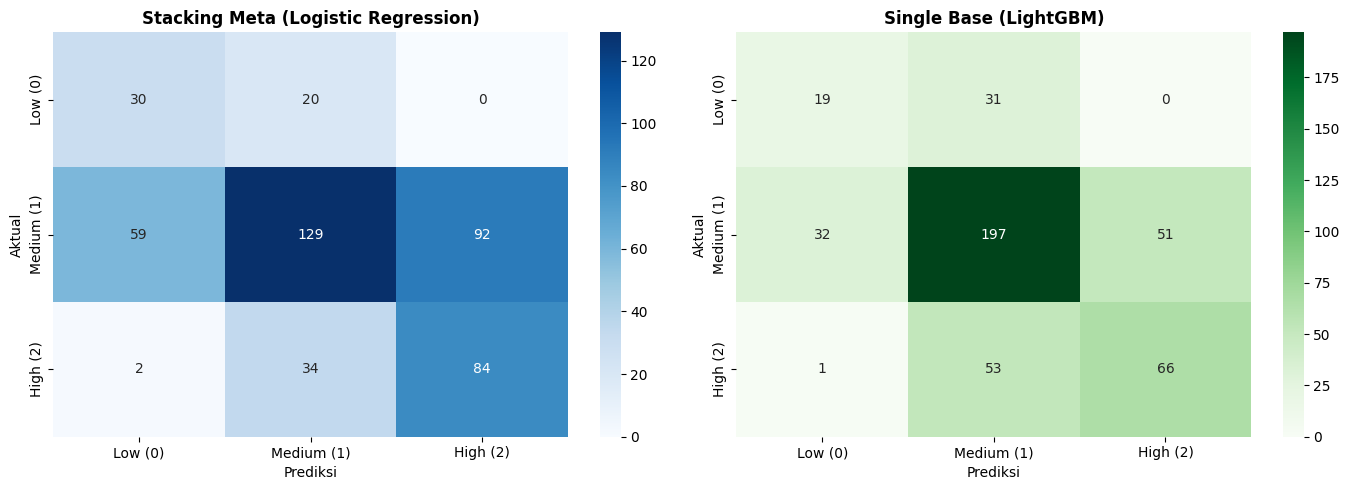


📊 CLASSIFICATION REPORT: STACKING (Logistic Regression)
              precision    recall  f1-score   support

           0       0.33      0.60      0.43        50
           1       0.70      0.46      0.56       280
           2       0.48      0.70      0.57       120

    accuracy                           0.54       450
   macro avg       0.50      0.59      0.52       450
weighted avg       0.60      0.54      0.55       450


📊 CLASSIFICATION REPORT: SINGLE BASE (LightGBM)
              precision    recall  f1-score   support

           0       0.37      0.38      0.37        50
           1       0.70      0.70      0.70       280
           2       0.56      0.55      0.56       120

    accuracy                           0.63       450
   macro avg       0.54      0.54      0.54       450
weighted avg       0.63      0.63      0.63       450



In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Matrix Stacking
cm_stack = confusion_matrix(y_test, y_pred_stack)
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low (0)', 'Medium (1)', 'High (2)'],
            yticklabels=['Low (0)', 'Medium (1)', 'High (2)'])
axes[0].set_title(f'Stacking Meta ({best_stack_name})', fontweight='bold')
axes[0].set_ylabel('Aktual')
axes[0].set_xlabel('Prediksi')

# Plot Matrix Base
cm_base = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Low (0)', 'Medium (1)', 'High (2)'],
            yticklabels=['Low (0)', 'Medium (1)', 'High (2)'])
axes[1].set_title(f'Single Base ({best_base_name})', fontweight='bold')
axes[1].set_ylabel('Aktual')
axes[1].set_xlabel('Prediksi')

plt.tight_layout()
plt.show()

# --- CLASSIFICATION REPORT ---
print("\n" + "="*60)
print(f"📊 CLASSIFICATION REPORT: STACKING ({best_stack_name})")
print("="*60)
print(classification_report(y_test, y_pred_stack))

print("\n" + "="*60)
print(f"📊 CLASSIFICATION REPORT: SINGLE BASE ({best_base_name})")
print("="*60)
print(classification_report(y_test, y_pred_base))